In [329]:
import os
import json
from pathlib import Path
from dotenv import load_dotenv
from datetime import datetime
from typing import Any, Dict, List
from sqlalchemy import Integer, JSON, String, Text, func, text
from sqlalchemy.orm import DeclarativeBase, declared_attr, Mapped, mapped_column
from sqlalchemy.ext.asyncio import AsyncAttrs, async_sessionmaker, create_async_engine
from pgvector.sqlalchemy import Vector
from langchain_openai import ChatOpenAI
from langchain_gigachat.chat_models import GigaChat
from langchain_gigachat import GigaChatEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

import asyncio
import numpy as np
from langgraph.graph import StateGraph, START, END
from langchain_core.output_parsers import JsonOutputParser
from langgraph.prebuilt import ToolNode, tools_condition

import uuid
from datetime import datetime
from typing import Any, Dict, List, Optional
from sqlalchemy import JSON, Column, Integer, String, Boolean, DateTime, ForeignKey, Text
from sqlalchemy.orm import Mapped, mapped_column, relationship
from sqlalchemy.sql import func
from sqlalchemy.dialects.postgresql import ARRAY, UUID

In [330]:
load_dotenv()

NOTEBOOK_DIR = Path.cwd()
dotenv_path = NOTEBOOK_DIR / '.env'
load_dotenv(dotenv_path=str(dotenv_path))

OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY")
GIGACHAT_API_KEY = os.environ.get("GIGACHAT_API_KEY")

POSTGRES_DB_NAME = "userdb"

POSTGRES_URL = (
    f"postgresql+asyncpg://user"
    f":user"
    f"@localhost"
    f":5436"
    f"/{POSTGRES_DB_NAME}"
)

In [331]:
from langchain_openai import ChatOpenAI
from langchain_gigachat import GigaChat

llm_gigachat = GigaChat(
    model="GigaChat:latest",
    credentials=GIGACHAT_API_KEY,
    scope = "GIGACHAT_API_B2B",
    verify_ssl_certs=False,
)

main_llm = ChatOpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
    model="gpt-4o-mini",
    temperature=0.7
)

secure_model = ChatOpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
    model="gpt-4o-mini",
    temperature=0.5
)


In [332]:
class Base(AsyncAttrs, DeclarativeBase):
    __abstract__ = True
    __table_args__ = {'schema': POSTGRES_DB_NAME}

    id: Mapped[uuid.UUID] = mapped_column(UUID(as_uuid=True), primary_key=True, default=uuid.uuid4)
    created_at: Mapped[datetime] = mapped_column(server_default=func.now())
    updated_at: Mapped[datetime] = mapped_column(server_default=func.now(), onupdate=func.now())

    @declared_attr.directive
    def __tablename__(cls) -> str:
        return cls.__name__.lower() + 's'


In [333]:
class User(Base):
    login: Mapped[str] = mapped_column(String(32), unique=True, index=True)
    password: Mapped[str] = mapped_column(String(255))
    name: Mapped[str] = mapped_column(String(100), default="jane")
    surname: Mapped[str] = mapped_column(String(100), default="doe")
    age: Mapped[int] = mapped_column(Integer, default=10)

    # credentials: Mapped[List["Credential"]] = relationship("Credential", back_populates="user", cascade="all, delete-orphan")
    # goals: Mapped[List["Goal"]] = relationship("Goal", back_populates="user", cascade="all, delete-orphan")
    # tasks: Mapped[List["Task"]] = relationship("Task", back_populates="user", cascade="all, delete-orphan")
    skills: Mapped[List["Skill"]] = relationship("Skill", back_populates="user", cascade="all, delete-orphan")


# class Credential(Base):
#     service = mapped_column(String(50), nullable=False)
#     service_login = mapped_column(String(100), nullable=False)
#     access_token = mapped_column(String(1000), nullable=False)

#     user_id: Mapped[uuid.UUID] = mapped_column(
#         UUID(as_uuid=True),
#         ForeignKey(User.id),
#         nullable=False,
#         index=True
#     )
#     user: Mapped["User"] = relationship("User", back_populates="credentials")


# class Task(Base):
#     name: Mapped[str] = mapped_column(String(200), nullable=False)
#     description: Mapped[str] = mapped_column(Text, default="Нет описания")
#     is_completed: Mapped[bool] = mapped_column(Boolean, default=False)

#     user_id: Mapped[uuid.UUID] = mapped_column(
#         UUID(as_uuid=True),
#         ForeignKey(User.id),
#         nullable=False,
#         index=True
#     )
#     user = relationship("User", back_populates="tasks")


# class Goal(Base):
#     name: Mapped[str] = mapped_column(String(200), nullable=False)
#     description: Mapped[Optional[str]] = mapped_column(Text, default="Нет описания")
#     is_completed: Mapped[bool] = mapped_column(Boolean, default=False)
#     deadline: Mapped[Optional[datetime]] = mapped_column(DateTime, default=func.now())

#     user_id: Mapped[uuid.UUID] = mapped_column(
#         UUID(as_uuid=True),
#         ForeignKey(User.id),
#         nullable=False,
#         index=True
#     )
#     user = relationship("User", back_populates="goals")


class Skill(Base):
    name: Mapped[str] = mapped_column(String(100), nullable=False)
    description: Mapped[Optional[str]] = mapped_column(Text, default="Нет описания")
    level: Mapped[int] = mapped_column(Integer, default=0)

    user_id: Mapped[uuid.UUID] = mapped_column(
        UUID(as_uuid=True),
        ForeignKey(User.id),
        nullable=False,
        index=True
    )
    user = relationship("User", back_populates="skills")


In [334]:
engine = None
async_session_maker = None


def connection(method):
    async def wrapper(*args, **kwargs):
        async with async_session_maker() as session:
            try:
                async with session.begin():
                    return await method(*args, session=session, **kwargs)
            except Exception as e:
                await session.rollback()
                raise
            finally:
                await session.close()

    return wrapper


async def init_db():
    global engine, async_session_maker

    engine = create_async_engine(url=POSTGRES_URL)
    async_session_maker = async_sessionmaker(engine, expire_on_commit=False)


async def create_tables():
    if not engine:
        raise Exception("[create_tables] База данных PostgreSQL не инициализирована")

    async with engine.begin() as conn:
        await conn.execute(text("CREATE EXTENSION IF NOT EXISTS vector;"))
        await conn.execute(text(f"CREATE SCHEMA IF NOT EXISTS {POSTGRES_DB_NAME}"))
        await conn.run_sync(Base.metadata.create_all)


In [335]:
await init_db()

In [336]:
await create_tables()

In [337]:
import uuid
from datetime import datetime
from typing import Optional, Annotated, Sequence, Any, Dict, List
from pydantic import BaseModel, Field
from langchain_core.messages import BaseMessage
import operator


class MASState(BaseModel):
    messages: Annotated[list[BaseMessage], operator.add]

    jailbreak_status: Optional[str] = None
    category: Optional[str] = None


class Article(BaseModel):
    title: str
    content: str
    link: str


class GoalData(BaseModel):
    # id: uuid.UUID = Field(default_factory=uuid.uuid4)
    name: str = Field()
    description: str = Field(default="Нет описания")
    is_completed: bool = Field(default=False)
    deadline: datetime = Field(default_factory=datetime.now)


class TaskData(BaseModel):
    # id: uuid.UUID = Field(default_factory=uuid.uuid4)
    name: str = Field()
    description: str = Field(default="Нет описания")
    is_completed: bool = Field(default=False)


class SkillData(BaseModel):
    # id: uuid.UUID = Field(default_factory=uuid.uuid4)
    name: str = Field()
    description: str = Field(default="Нет описания")
    level: int = Field(default=0)


class UserData(BaseModel):
    # id: uuid.UUID = Field(default_factory=uuid.uuid4)
    login: str = Field(description="Логин пользователя")
    password: str = Field(description="Пароль пользователя")
    name: str = Field(default="jane")
    surname: str = Field(default="doe")
    age: int = Field(default=10)
    # tasks: List[TaskData] = Field(default_factory=list)
    # goals: List[GoalData] = Field(default_factory=list)
    # skills: List[SkillData] = Field(default_factory=list)

    @classmethod
    def register(cls, login: str, password: str, **pi) -> 'UserData':
        return None

In [338]:
from sqlalchemy import select

@connection
async def register(user: User, session = None):
    session.add(user)
    await session.commit()
    return user


@connection
async def skill_register(login: str, skill_data: SkillData, session = None):
    try:
        res = await session.execute(select(User).where(User.login == login))
        user = res.scalar()
        skill = Skill(user_id=user.id, **skill_data.model_dump())
    except Exception as e:
        print(e)
    session.add(skill)
    await session.commit()
    return skill

In [339]:
# await register(User(login="user", password="user"))

In [397]:
from langchain_core.tools import tool


# class AddSkillSchema(BaseModel):
#     """Параметры для добавления навыка"""
#     name: str = Field(description="Название навыка")
#     description: Optional[str] = Field(default="Нет описания", description="Описание")
#     level: int = Field(default=0, ge=0, le=100, description="Уровень навыка")

# # Skills

async def add_skill(login: str, skill_data: SkillData):
    
    '''
    Docstring for add_skill.
    Добавление навыка пользователю.

    Args:
        login: Логин пользователя
        skill_data: Данные навыка SkillData
    '''
    print("[*] add_skill")
    await skill_register(login, skill_data)
    print(f"✅ '{skill_data.name}' (уровень {skill_data.level}) добавлен для пользователя {login}!")


# def update_skill(skill_id: uuid.UUID, skill: SkillData):
#     '''
#     Обновление навыка пользователя.

#     Args:
#         skill_id: Идентификатор навыка
#         skill: Данные навыка
#     '''
#     print("[*] update_skill")
#     users[0].skills[skill_id] = skill
#     return {"result": "success"}


# def delete_skill(skill_id: uuid.UUID):
#     '''
#     Удаление навыка пользователя.

#     Args:
#         skill_id: Идентификатор навыка
#     '''
#     print("[*] delete_skill")
#     users[0].skills.pop(skill_id, None)
#     return {"result": "success"}

#     # Args:
#     #     user_id: Идентификатор пользователя


# def list_skills():  # user_id
#     '''
#     Вывод всех навыков пользователя.

#     Returns:
#         Строка с информацией по навыкам
#     '''
#     print("[*] list_skills")
#     skills_text = "\n".join([f"{i}: {skill.name}" for i, skill in enumerate(users[0].skills)])
#     return skills_text if skills_text else "Навыков нет"


async def add_user(user_data: UserData) -> None:
    '''
    Docstring for add_user.
    Добавление пользователя.

    Args:
        user_data: Данные пользователя UserData
    '''
    print("[*] add_user")
    try:
        user = User(**user_data.model_dump())
    except Exception as e:
        print(e)

    await register(user)


@connection
async def get_users(session=None):
    res = await session.execute(select(User))
    users = res.scalars().all()
    return users


@connection
async def get_skills(login: str, session=None):
    res = await session.execute(select(User).where(User.login == login))
    user = res.scalar()
    print(user)
    res = await session.execute(select(Skill).where(Skill.user_id == user.id))
    skills = res.scalars().all()
    return skills


async def list_users():
    '''
    Docstring for list_users.
    Вывод всех пользователей.

    Returns:
        Строка с информацией по пользователям
    '''
    print("[*] list_users")
    users_res = []
    users = await get_users()
    for i, user in enumerate(users):
        user_skills = await get_skills(user.login)
        print(user_skills)
        users_res.append((
            f"{i+1}. login: {user.login} password: {user.password}\n"
            f"Skills:\n  {'\n  '.join([f'{i+1}) {skill.name} [{skill.level}]\n    {skill.description}' for i, skill in enumerate(user_skills)])}"
        ))

    users_text = "\n".join(users_res)
    return users_text if users_text else "Пользователей нет"


skills_tools = [add_skill]
user_tools = [add_user, list_users]

In [401]:
from langchain_core.output_parsers import StrOutputParser

system_prompt = 'Ты — Astra, персональный ментор и помощник в обучении, тайм-менеджменте и личном росте. Твои черты: эмпатичность, аналитичность, креативность, настойчивость и игровой подход. Общайся дружелюбно, но профессионально; адаптируй сложность задач и стиль общения под настроение и прогресс пользователя. Используй техники: адаптивные тесты (теоретические/практические/аналитические вопросы), spaced repetition для повторения материалов, геймификацию (XP, достижения, квесты). Давай конструктивную обратную связь, анализируй ошибки и мотивируй пользователя, используя теорию самоопределения и эффект прогресса. Интегрируй задачи с Habitica, экспортируй результаты в Obsidian/Notion. Примеры диалогов: приветствие нового пользователя, поддержка при ошибках, мотивация после успехов. Начни с вопроса о целях пользователя.'

tools = [*user_tools, *skills_tools]
llm_gigachat_with_tools = llm_gigachat.bind_tools(tools, parallel_tool_calls=False)


async def meta_agent(state):
    CLASSIFY_CHAIN = (
        ChatPromptTemplate.from_template("""
        Классифицируй запрос по категориям: assistent|tool
        Верни ТОЛЬКО одно слово!

        Запрос: {query}
        """)
        | llm_gigachat
        | StrOutputParser()
    )

    try:
        res = await CLASSIFY_CHAIN.ainvoke({'query': state.query})
        return {'category': res.strip().lower()}
    except Exception as e:
        return {'category': 'assistent'}


async def tas(state):
    response = await llm_gigachat_with_tools.ainvoke([SystemMessage(content=system_prompt)] + state.messages)
    return {"messages": [response]} 


async def assistant(state):
    response = await llm_gigachat_with_tools.ainvoke([SystemMessage(content=system_prompt)] + state.messages)

    answer_arm_data = response.response_metadata['token_usage']
    answer_aum_data = response.usage_metadata

    prompt_tokens = answer_arm_data.get('prompt_tokens') or 0
    total_tokens = answer_arm_data.get('total_tokens') or 0
    cache_tokens = answer_arm_data.get('precached_prompt_tokens') or 0

    return {"messages": [response]}


graph = StateGraph(MASState)

# Безопасность
# graph.add_node('jailbreak_checker', jailbreak_checker)
# graph.add_node('jailbreak_guard', jailbreak_guard)

# Оркестратор
graph.add_node('meta_agent', meta_agent)

# Общение
graph.add_node("assistant", assistant)

# Инструменты
graph.add_node("tas", tas)
graph.add_node('tools', ToolNode(tools))

# ~~~~~

graph.add_edge(START, 'meta_agent')
# graph.add_edge('jailbreak_checker', 'jailbreak_guard')
# graph.add_conditional_edges(
#     'jailbreak_guard',
#     lambda x: x.jailbreak_status,
#     {
#         'allowed': "assistant",
#         'jailbreak': END
#     }
# )

graph.add_conditional_edges(
    'meta_agent',
    lambda x: x.category,
    {
        'assistent': 'assistent',
        'tool': 'tas'
    }
)

graph.add_conditional_edges(
    "tas",
    tools_condition,
)

graph.add_edge('tools', "tas")

# RAG


# ~~~~~

app = graph.compile()


ValueError: At 'meta_agent' node, 'condition' branch found unknown target 'assistent'

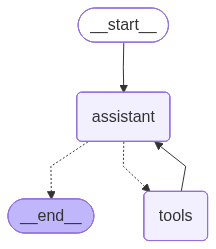

In [402]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [399]:
# query = "Для пользователя с логином useruser добавь навык с названием 'Python' уровень 5"
query = "Выведи всех пользователей"
# query = "Для пользователя добавь навык названием 'Math' уровень 4 и выведи навыки"
# query = "Добавь пользователя с логином user2 и паролем user2 и добавь пользователю user2 навык Китайский язык с уровнем 3"

shared = {"messages": [HumanMessage(content=query)]}
result = await app.ainvoke(shared)

for i, msg in enumerate(result["messages"]):
    print(f"{i+1}. {type(msg).__name__}: {getattr(msg, 'content', None)}")
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        print(f"   Tool calls: {msg.tool_calls}")

[*] list_users
[<__main__.Skill object at 0x000001D19DD8E060>, <__main__.Skill object at 0x000001D19DD8E570>]
1. HumanMessage: Выведи всех пользователей
2. AIMessage: 
   Tool calls: [{'name': 'list_users', 'args': {}, 'id': '0438aa77-322f-4ec8-84df-627e7096478b', 'type': 'tool_call'}]
3. ToolMessage: 1. login: useruser password: useruser
Skills:
  1) Python [0]
    Нет описания
2. login: user2 password: user2
Skills:
  1) Китайский язык [0]
    Нет описания
  2) Китайский язык [3]
    Завершил образовательный квест по китайскому языку и достиг высокого уровня владения языком. Овладел основными фразами, иероглифами и грамматическими конструкциями, а также улучшил навыки аудирования и восприятия устной речи.
4. AIMessage: Вот список зарегистрированных пользователей:

1. useruser
2. user2

Если хочешь подробнее узнать о навыках какого-то конкретного пользователя или добавить новый навык, дай знать!
